<a href="https://colab.research.google.com/github/Aadya04/A-B-Testing/blob/main/NLP_FINAL_PROJECT_checking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load data
df_org = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')

# Check shape and sample
print(df_org.shape)

(200083, 5)


In [ ]:
df_org.isnull().sum()

,0
url,0
date,0
language,0
title,0
text,0


In [ ]:
import pandas as pd
import re

# URL and HTML regex patterns
url_pattern = re.compile(r'http\S+|www\S+|https\S+|@\w+|\S+@\S+')
html_pattern = re.compile(r'<.*?>')

def clean_article_text(text):
    if pd.isna(text):
        return ""

    # Remove URLs and emails
    text = url_pattern.sub('', text)

    # Remove HTML tags
    text = html_pattern.sub('', text)

    # Remove line breaks, tabs, carriage returns
    text = re.sub(r'[\r\n\t]+', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Remove boilerplate content (customize per dataset)
    boilerplate_phrases = [
        r"home business.*?privacy policy",
        r"contact us.*?business news this week",
        r"follow on facebook.*?copyright © \d{4}",
        r"previous.*?next",
    ]
    for pattern in boilerplate_phrases:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # Lowercase and strip whitespace
    text = text.lower().strip()

    return text


df_1 = df_org.copy()

# Apply the cleaning function to df_1 only
df_1['clean_text'] = df_1['text'].astype(str).apply(clean_article_text)


In [ ]:
print(df_1.shape)

(200083, 6)


In [ ]:
df_2 = df_1[df_1['language'] == 'en'].copy()

In [ ]:
print(df_2.shape)

(200083, 6)


In [ ]:
# --- Step 1: Define Domain Keyword Buckets ---

KEYWORD_CATEGORIES = {
    'tech_terms': [
        'artificial intelligence', 'machine learning', 'deep learning', 'data science', 'ai', 'ml', 'llm', 'nlp',
        'neural network', 'natural language processing', 'computer vision', 'reinforcement learning',
        'conversational ai', 'generative ai', 'large language model', 'transformer',
        'chatgpt', 'openai', 'chatbot', 'bert', 'gpt', 'lstm', 'automation', 'deep seek',
        'deepseek', 'gemini', 'copilot',
        'vision transformer', 'prompt engineering','self-supervised learning', 'auto-regressive model', 'text-to-image model',
        'ai model', 'ai algorithm', 'ai tool'
    ],
    'workforce_impact': [
        'automation', 'industry', 'industries', 'jobs', 'employment', 'productivity', 'workforce','transform', 'disrupt', 'replace', 'automate',
        'job', 'employment', 'career', 'sector', 'profession', 'work',
        'skill', 'efficiency', 'cognitive task', 'physical task',
         'abstract thought', 'reasoning', 'job displacement',
        'job augmentation', 'job loss', 'job creation', 'task replacement',
        'employee upskilling', 'future of work'
    ],
    'sector_mentions': [
        'legal', 'law', 'legal services', 'architecture', 'architectural design',
        'social sciences', 'sociology', 'office tasks', 'administrative work', 'clerical work',
        'construction', 'installation', 'building maintenance', 'healthcare', 'medical',
        'cybersecurity', 'journalism', 'travel', 'hospitality', 'education', 'teaching',
        'human resource', 'recruitment', 'manufacturing', 'automotive', 'robotics',
        'real estate', 'marketing', 'retail', 'transportation', 'logistics', 'finance',
        'banking', 'customer service', 'call center', 'insurance', 'consulting', 'public sector'
    ]
}

In [ ]:
def filter_relevant_article(record, text_field='clean_text'):
    """
    Returns True if article's clean_text (which includes title and body)
    contains at least one keyword from 'tech_terms' and one from 'workforce_impact'.
    """
    try:
        body = str(record[text_field])[:5000].lower()  # Limit to 5000 chars for performance

        has_tech = any(term in body for term in KEYWORD_CATEGORIES['tech_terms'])
        has_impact = any(term in body for term in KEYWORD_CATEGORIES['workforce_impact'])

        return has_tech and has_impact
    except Exception as e:
        return False

In [ ]:
# Apply filter
df_filtered = df_2[df_2.apply(filter_relevant_article, axis=1)]

# Check result
print(f"Original dataset: {df_2.shape[0]} articles")
print(f"Filtered dataset: {df_filtered.shape[0]} relevant articles")

Original dataset: 200083 articles
Filtered dataset: 178209 relevant articles


In [ ]:
df_filtered.to_csv('df_filtered1.csv', index=False)

In [ ]:
#df_final = pd.read_csv("/content/drive/MyDrive/df_final.csv")
#df_final.shape

In [ ]:
df_token_filtered = df_filtered.copy()
df_token_filtered['token_count'] = df_token_filtered['clean_text'].apply(lambda x: len(x.split()))
df_token_filtered = df_token_filtered[df_token_filtered['token_count'] >= 30].copy()
print(f"After token count filtering: {df_token_filtered.shape[0]} rows")

After token count filtering: 178154 rows


In [ ]:
df_token_filtered.to_csv('df_filtered2.csv', index=False)

In [ ]:
!pip install langdetect

In [ ]:
df_lang = df_token_filtered.copy()

In [ ]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df_lang = df_token_filtered.copy()

# Apply language detection only to the clean_text field
df_lang['detected_lang'] = df_lang['clean_text'].apply(detect_language)

# Filter again for truly English articles
df_final_lang_checked = df_lang[df_lang['detected_lang'] == 'en'].copy()

print(f"Final truly-English articles: {df_final_lang_checked.shape[0]}")

In [ ]:
df_final_lang_checked.to_csv('df_final.csv', index=False)

In [ ]:
pip install nltk

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import re

def simple_tokenize(text):
    return re.findall(r'\b\w\w+\b', text.lower())

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special chars
    text = text.lower()
    tokens = simple_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

In [ ]:
df_final2 = df_token_filtered.copy()
df_final2.loc[:, 'clean_text'] = df_final2['clean_text'].astype(str).apply(clean_text)
df_final2.shape

(178154, 7)

In [ ]:
!pip install -q spacy

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

# Load the small English model
nlp = spacy.load("en_core_web_sm")

In [ ]:
def lemmatize_text(text):
    doc = nlp(text)
    # Return a string of lemmatized tokens excluding stopwords and punctuation
    return ' '.join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])

In [ ]:
df_final2['lemmatized_text'] = df_final2['clean_text'].astype(str).apply(lemmatize_text)

In [ ]:
df_final2.to_csv('df_final2.csv', index=False)

In [ ]:
df_final2 = pd.read_csv("/content/df_final2.csv")
df_final2.shape

(178154, 7)

In [ ]:
df_final2.to_parquet('df_final2.parquet', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/topic_modeling', exist_ok=True)


In [ ]:
df_final2.to_parquet('/content/drive/MyDrive/topic_modeling/df_final2.parquet', index=False)


In [ ]:
import pandas as pd

# Initialize a dict to store counts at each step
article_counts = {}

# 1. Original dataset
article_counts['Original'] = df_org.shape[0]

# 2. After cleaning text (same number of articles, just added clean_text column)
article_counts['After Cleaning Text'] = df_1.shape[0]

# 3. After filtering English language articles
article_counts['English Language'] = df_2.shape[0]

# 4. After filtering by domain keywords
article_counts['Domain Keyword Filter'] = df_filtered.shape[0]

#5.After token count filtering (min 30 tokens)
article_counts["After removing articles that are too short"] = df_token_filtered.shape[0]

# 6. After removing stop words and performing lemmatization
article_counts['After Stop Words Removal and Lemmatization'] = df_final2.shape[0]

# Convert to DataFrame for better display
counts_df = pd.DataFrame(list(article_counts.items()), columns=['Filter Step', 'Number of Articles'])

counts_df


,Filter Step,Number of Articles
0,Original,200083
1,After Cleaning Text,200083
2,English Language,200083
3,Domain Keyword Filter,178209
4,After removing articles that are too short,178154
5,After Stop Words Removal and Lemmatization,178154


In [ ]:
import plotly.express as px

# Set the correct order for steps based on their appearance in the DataFrame
counts_df['Filter Step'] = pd.Categorical(counts_df['Filter Step'], categories=counts_df['Filter Step'], ordered=True)

# Funnel chart with article counts at each processing step
fig = px.funnel(
    counts_df,
    x='Number of Articles',
    y='Filter Step',
    title='Article Count at Each Processing Step',
    labels={'Number of Articles': 'Articles Remaining'},
    text='Number of Articles'
)

fig.update_traces(textposition='inside', textfont_size=14)
fig.update_layout(yaxis_title='', xaxis_title='Articles Remaining')
fig.show()


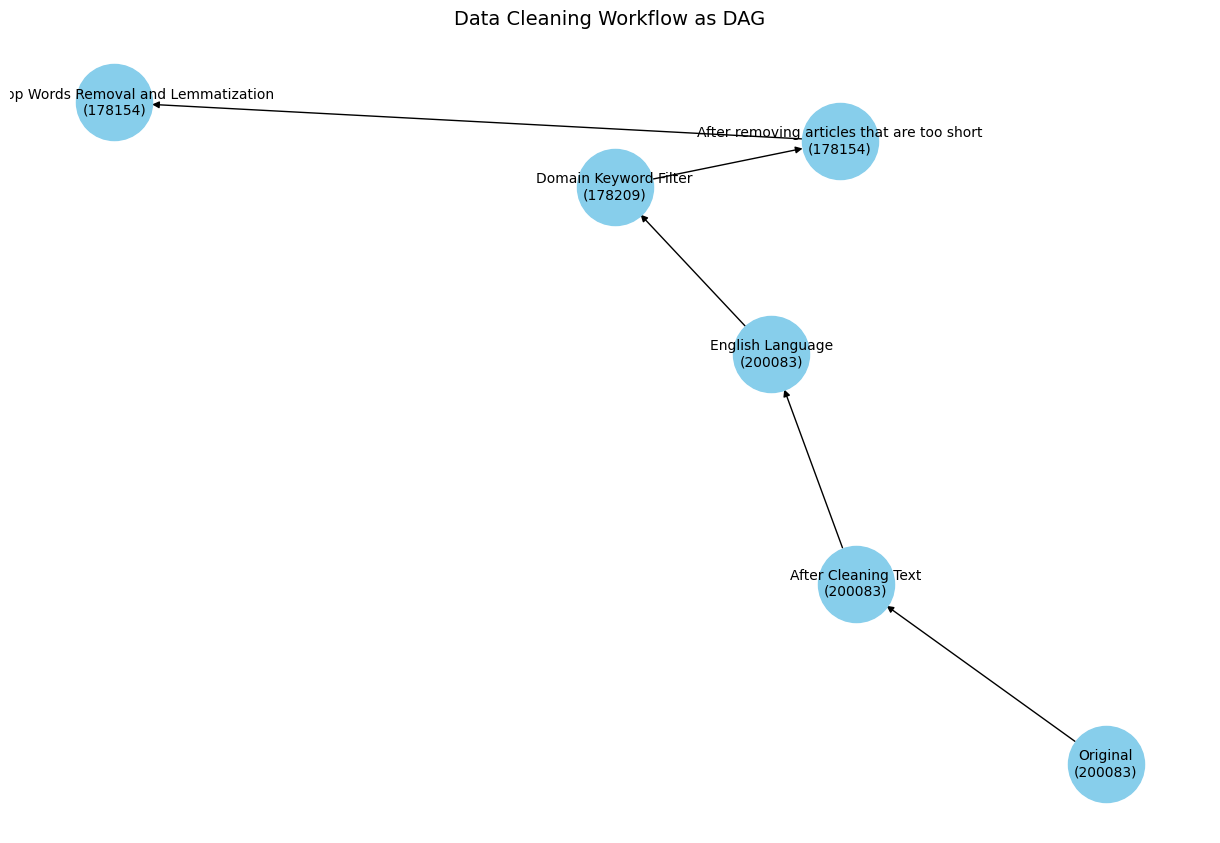

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G = nx.DiGraph()

steps = list(counts_df['Filter Step'])
counts = list(counts_df['Number of Articles'])

# Add nodes with labels as step + count
for i, step in enumerate(steps):
    G.add_node(step + f"\n({counts[i]})")

# Add directional edges
for i in range(len(steps) - 1):
    G.add_edge(steps[i] + f"\n({counts[i]})", steps[i+1] + f"\n({counts[i+1]})")

# Draw
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # or use `graphviz_layout(G, prog='dot')` for top-down
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, arrows=True)
plt.title("Data Cleaning Workflow as DAG", fontsize=14)
plt.show()


In [ ]:
import plotly.express as px

# Reorder for clarity
counts_df['Filter Step'] = pd.Categorical(counts_df['Filter Step'], categories=counts_df['Filter Step'], ordered=True)

fig = px.bar(
    counts_df,
    y='Filter Step',
    x='Number of Articles',
    orientation='h',
    text='Number of Articles',
    title='Progressive Filtering of Articles',
    labels={'Number of Articles': 'Articles Remaining'}
)

fig.update_traces(textposition='outside', textfont_size=12)
fig.update_layout(yaxis_title='', xaxis_title='Articles Remaining', bargap=0.3)
fig.show()


In [ ]:
!pip install bertopic[all] sentence-transformers umap-learn hdbscan


In [ ]:
pip install bertopic[all] sentence-transformers


In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

AttributeError: module 'numpy' has no attribute 'dtypes'

In [ ]:
texts_cleaned = df_final2['clean_text'].dropna().tolist()

In [ ]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import numpy as np
import os
import pickle

# Parameters
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
batch_size = 5000
checkpoint_dir = "embedding_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Resume support
start_batch = 0
existing_checkpoints = sorted([
    int(fname.split('_')[-1].split('.')[0])
    for fname in os.listdir(checkpoint_dir)
    if fname.startswith("embedding_batch_")
])
if existing_checkpoints:
    start_batch = max(existing_checkpoints) + 1
    print(f"Resuming from batch {start_batch}...")

# Main embedding loop
all_embeddings = []

for i in range(start_batch * batch_size, len(texts_cleaned), batch_size):
    batch_num = i // batch_size
    batch_texts = texts_cleaned[i:i+batch_size]

    print(f"Processing batch {batch_num} ({i} to {i+batch_size})...")
    batch_embeddings = embedding_model.encode(batch_texts, show_progress_bar=True)

    # Save each batch to disk
    with open(f"{checkpoint_dir}/embedding_batch_{batch_num}.pkl", "wb") as f:
        pickle.dump(batch_embeddings, f)

# Combine all saved batches into one array
all_embeddings = []

for i in sorted(existing_checkpoints + list(range(start_batch, (len(texts_cleaned) + batch_size - 1) // batch_size))):
    with open(f"{checkpoint_dir}/embedding_batch_{i}.pkl", "rb") as f:
        batch = pickle.load(f)
        all_embeddings.append(batch)

all_embeddings = np.vstack(all_embeddings)
print(f"Total embeddings shape: {all_embeddings.shape}")

# Initialize BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=50,
    nr_topics=100,
    verbose=True
)

Processing batch 0 (0 to 5000)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Processing batch 1 (5000 to 10000)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Processing batch 2 (10000 to 15000)...


...

Processing batch 3 (15000 to 20000)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Processing batch 4 (20000 to 25000)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# 1. Embedding Model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")  # Fast + reliable

# 5. Initialize BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size = 50,
    nr_topics=100,
    verbose= True
)

In [ ]:
topics, probs = topic_model.fit_transform(texts_cleaned)

In [ ]:
# STEP 8: Save checkpoint
topic_model.save("bertopic_checkpoint", serialization="safetensors")

In [ ]:
topic_info.to_csv('bertopic_topics.csv', index=False)

In [ ]:
topic_info = topic_model.get_topic_info()
topic_info

In [ ]:
for topic_id in range(10):
    print(f"Topic {topic_id}: {topic_model.get_topic(topic_id)[:5]}")

In [ ]:
topic_model.visualize_barchart(top_n_topics=10)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# --- 1. Number of topics found (excluding outliers, i.e., topic -1) ---
n_topics_bertopic = len(topic_info[topic_info['Topic'] != -1])
print(f"\nNumber of topics found by BERTopic: {n_topics_bertopic}")



In [ ]:
# --- 2. Top words for each topic (excluding topic -1) ---
print("\nTop words for each BERTopic topic:")

for topic_id in topic_info['Topic']:
    if topic_id != -1:
        topic_words = topic_model.get_topic(topic_id)
        words_only = [word for word, _ in topic_words]
        print(f"Topic {topic_id}: {', '.join(words_only)}")



In [ ]:
# --- 3. Word Cloud Function ---
def create_bertopic_wordcloud(model, topic_id):
    """
    Create and display a word cloud for a specific BERTopic topic.
    """
    if topic_id == -1:
        return
    topic_words = model.get_topic(topic_id)
    word_freq = {word: score for word, score in topic_words}
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=50,
        colormap='viridis'
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for BERTopic Topic {topic_id}')
    plt.show()



In [ ]:
# --- 4. Display Word Clouds for All Topics (excluding outlier) ---
for topic_id in topic_info['Topic']:
    create_bertopic_wordcloud(topic_model, topic_id)

In [ ]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!pip install gensim==4.3.1 numpy==1.23.5 scipy==1.10.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 18.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cvxpy 1.6.5 requires scipy>=1.11.0, but you have scipy 1.10.1 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.5.1 requires scipy>=1.11.1, but

In [ ]:
import os
import pickle
import joblib
import gensim
import nltk
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel, LdaMulticore
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

data = df_final2["lemmatized_text"].values.tolist()
data_words = list(sent_to_words(data))


In [ ]:
if os.path.exists("lda_id2word.dict") and os.path.exists("lda_corpus.mm"):
    id2word = corpora.Dictionary.load("lda_id2word.dict")
    corpus = corpora.MmCorpus("lda_corpus.mm")
else:
    id2word = corpora.Dictionary(data_words)
    corpus = [id2word.doc2bow(text) for text in data_words]
    id2word.save("lda_id2word.dict")
    corpora.MmCorpus.serialize("lda_corpus.mm", corpus)

In [ ]:
topics_range = range(5, 31, 5)
passes = 5
iterations = 50
RANDOM_STATE = 0
subset_corpus = corpus[:1000]
subset_texts = data_words[:1000]
coherence_path = "coherence_scores.pkl"

if os.path.exists(coherence_path):
    with open(coherence_path, "rb") as f:
        coherence_scores = pickle.load(f)
else:
    coherence_scores = []
    for num_topics in topics_range:
        model = LdaMulticore(corpus=subset_corpus,
                             id2word=id2word,
                             num_topics=num_topics,
                             random_state=RANDOM_STATE,
                             passes=passes,
                             iterations=iterations,
                             workers=2)
        coherence_model = CoherenceModel(model=model,
                                         texts=subset_texts,
                                         dictionary=id2word,
                                         coherence='c_v')
        coherence_scores.append(coherence_model.get_coherence())
    with open(coherence_path, "wb") as f:
        pickle.dump(coherence_scores, f)


In [ ]:
plt.plot(topics_range, coherence_scores)
plt.xlabel("Num Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence Score by Topic Count")
plt.show()


In [ ]:
if os.path.exists("tf_matrix.pkl"):
    tf_matrix = joblib.load("tf_matrix.pkl")
    tf_vectorizer = joblib.load("tf_vectorizer.pkl")
else:
    tf_vectorizer = CountVectorizer(max_df=0.95, min_df=5, max_features=1000)
    tf_matrix = tf_vectorizer.fit_transform(df_clean["clean_text"])
    joblib.dump(tf_matrix, "tf_matrix.pkl")
    joblib.dump(tf_vectorizer, "tf_vectorizer.pkl")

if os.path.exists("sklearn_lda_model.pkl"):
    lda_model = joblib.load("sklearn_lda_model.pkl")
else:
    lda_model = LatentDirichletAllocation(n_components=optimal_n_topics,
                                          max_iter=10,
                                          learning_method='online',
                                          random_state=RANDOM_STATE)
    lda_model.fit(tf_matrix)
    joblib.dump(lda_model, "sklearn_lda_model.pkl")


In [ ]:
def display_topics(model, feature_names, n_top_words=15):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

vocab = tf_vectorizer.get_feature_names_out()
display_topics(lda_model, vocab)
